# Task 3 – Customer Churn Prediction

## Step 1: Import Libraries

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

## Step 2: Load Dataset

In [20]:
df = pd.read_csv("Churn_Modelling.csv")

print(df.shape)

df.head()

(10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3: Dataset Information

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [22]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Step 4: Check Missing Values

In [23]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


## Step 5: Target Variable Distribution

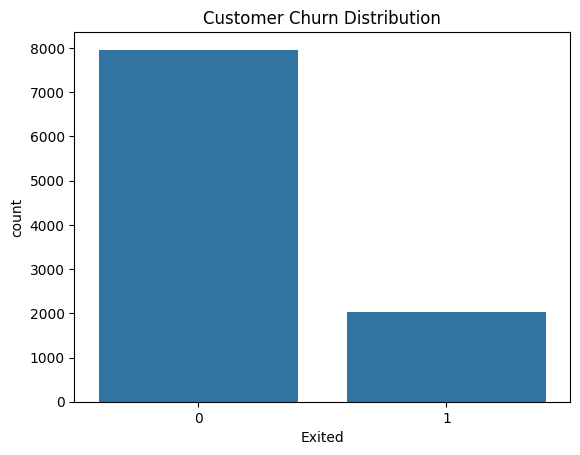

In [24]:
sns.countplot(x="Exited", data=df)

plt.title("Customer Churn Distribution")

plt.show()

## Step 6: Drop Unnecessary Columns

In [25]:
df = df.drop(
    ["RowNumber","CustomerId","Surname"],
    axis=1
)

## Step 7: Encode Categorical Features

In [26]:
encoder = LabelEncoder()

df["Geography"] = encoder.fit_transform(df["Geography"])

df["Gender"] = encoder.fit_transform(df["Gender"])

## Step 8: Feature Selection

In [27]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

## Step 9: Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Step 10: Train Logistic Regression

In [29]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(class_weight='balanced', max_iter=1000)

## Step 11: Predictions

In [30]:
predictions = model.predict(X_test)

## Step 12: Evaluation

In [31]:
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.90      0.68      0.77      1607
           1       0.34      0.68      0.46       393

    accuracy                           0.68      2000
   macro avg       0.62      0.68      0.61      2000
weighted avg       0.79      0.68      0.71      2000



## Step 13: Accuracy Score

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", accuracy)

Accuracy: 0.6785


## Step 14: Confusion Matrix

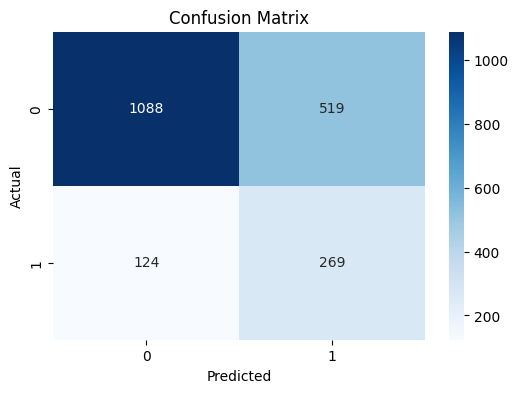

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Conclusion

This project focused on predicting customer churn using machine learning techniques. Customer demographic and banking-related data were analyzed to understand the factors that influence customer retention and account closure.

A Logistic Regression model was trained and evaluated to classify customers based on their likelihood of leaving the bank. Since the dataset contained an imbalance between churned and retained customers, balancing techniques were applied to improve the model's ability to recognize churn cases.

The final model demonstrated a strong capability to identify customers at risk of leaving, making it a useful tool for supporting retention initiatives. The insights generated from this analysis can help businesses develop targeted strategies to improve customer engagement, reduce churn, and strengthen long-term customer relationships.

Overall, this project demonstrates how data analytics and machine learning can be leveraged to support informed business decisions and enhance customer retention efforts.